In [1]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

# Load the CSV files for each cluster
df_cluster1 = pd.read_csv('/hpc/group/xielab/of21/re_pathway_results_aab_cluster1.csv')
df_cluster2 = pd.read_csv('/hpc/group/xielab/of21/re_pathway_results_aab_cluster2.csv')

# If your CSVs don't already include a 'Cluster' column, add them:
if 'Cluster' not in df_cluster1.columns:
    df_cluster1['Cluster'] = 'Cluster 1'
if 'Cluster' not in df_cluster2.columns:
    df_cluster2['Cluster'] = 'Cluster 2'

# Combine the two DataFrames into one
df = pd.concat([df_cluster1, df_cluster2], ignore_index=True)

# Apply the Benjamini-Hochberg FDR correction to the "p-value" column
_, adj_pvals, _, _ = multipletests(df["p-value"], alpha=0.05, method='fdr_bh')
df["adjusted p-value"] = adj_pvals

# Split the combined DataFrame back into cluster-specific DataFrames
df_cluster1_fdr = df[df["Cluster"] == "Cluster 1"]
df_cluster2_fdr = df[df["Cluster"] == "Cluster 2"]

# Save the updated DataFrames to new CSV files
df_cluster1_fdr.to_csv('/hpc/group/xielab/of21/re_pathway_results_aab_cluster1_fdr.csv', index=False)
df_cluster2_fdr.to_csv('/hpc/group/xielab/of21/re_pathway_results_aab_cluster2_fdr.csv', index=False)



In [2]:
# Define a function to assign value based on adjusted p-value threshold
def assign_value(adj_p):
    return 1 if adj_p < 0.05 else -1

# Process each cluster separately
for cluster in ["Cluster 1", "Cluster 2"]:
    # Filter by cluster
    df_cluster = df[df["Cluster"] == cluster].copy()
    # Create new 'Value' column using the thresholded adjusted p-value
    df_cluster["Value"] = df_cluster["adjusted p-value"].apply(assign_value)
    # Rename and add constant columns
    df_cluster = df_cluster.rename(columns={"pathway": "Pathway.Name"})
    df_cluster["Type"] = "CPACT"
    # Select only the required columns and preserve the order
    df_out = df_cluster[["Pathway.Name", "Type", "Value"]]
    
    # Save to CSV with appropriate file name in the given directory
    filename = f"/work/of21_work/AAB{cluster.replace(' ', '').lower()}CPACT.csv"
    df_out.to_csv(filename, index=False)

    print(f"Saved file for {cluster} to {filename}")

Saved file for Cluster 1 to /work/of21_work/AABcluster1CPACT.csv
Saved file for Cluster 2 to /work/of21_work/AABcluster2CPACT.csv


In [3]:
import pandas as pd

test_pathways = [
"Apoptosis",
"Insulin signaling pathway",
"AMPK signaling pathway",
"Autophagy",
"Cytokine-cytokine receptor interaction",
"FoxO signaling pathway",
"HIF-1 signaling pathway",
"Longevity regulating pathway",
"MAPK signaling pathway",
"Mineral absorption",
"PPAR signaling pathway",
"Protein processing in endoplasmic reticulum",
"Rap1 signaling pathway",
"cGMP-PKG signaling pathway",
"mTOR signaling pathway"
]
# Load the three CSV files
cpact_scores_ctrl_t1d = pd.read_csv("/hpc/group/xielab/of21/pancreas_ctrl_and_t1d_effect_sizes")
cpact_scores_cluster1 = pd.read_csv("/hpc/group/xielab/of21/re_pathway_results_aab_cluster1_fdr.csv")
cpact_scores_cluster2 = pd.read_csv("/hpc/group/xielab/of21/re_pathway_results_aab_cluster2_fdr.csv")

cpact_scores_ctrl_t1d.rename(columns={"fdr_p": "adjusted p-value"}, inplace=True)
cpact_scores_cluster1.rename(columns={"Cluster": "Group"}, inplace=True)
cpact_scores_cluster2.rename(columns={"Cluster": "Group"}, inplace=True)




# Append the rows of all three DataFrames
combined_df = pd.concat([cpact_scores_ctrl_t1d, cpact_scores_cluster1, cpact_scores_cluster2], 
                        ignore_index=True)

# Filter combined_df to keep only rows where the "pathway" column is in test_pathways
filtered_df = combined_df[combined_df["pathway"].isin(test_pathways)]

In [4]:
filtered_df

,pathway,p-value,z-score,Group,adjusted p-value
0,Autophagy,0.004975,22.610140,Ctrl,0.010333
1,Protein processing in endoplasmic reticulum,0.004975,12.109680,Ctrl,0.010333
2,mTOR signaling pathway,0.004975,9.848764,Ctrl,0.010333
3,MAPK signaling pathway,0.004975,44.961010,Ctrl,0.010333
4,Apoptosis,0.208955,-0.090961,Ctrl,0.282089
5,Longevity regulating pathway,0.004975,21.049610,Ctrl,0.010333
6,HIF-1 signaling pathway,0.004975,19.432770,Ctrl,0.010333
7,AMPK signaling pathway,0.004975,25.244940,Ctrl,0.010333
9,PPAR signaling pathway,0.004975,10.418620,Ctrl,0.010333
10,FoxO signaling pathway,0.004975,18.555420,Ctrl,0.010333


In [5]:
# Define a function to assign value based on adjusted p-value threshold
def assign_value(adj_p):
    return 1 if adj_p < 0.05 else -1

# Process each cluster separately
for cluster in ["Cluster 1", "Cluster 2"]:
    # Filter by cluster
    df_cluster = df[df["Cluster"] == cluster].copy()
    # Create new 'Value' column using the thresholded adjusted p-value
    df_cluster["Value"] = df_cluster["adjusted p-value"].apply(assign_value)
    # Rename and add constant columns
    df_cluster = df_cluster.rename(columns={"pathway": "Pathway.Name"})
    df_cluster["Type"] = "CPACT"
    # Select only the required columns and preserve the order
    df_out = df_cluster[["Pathway.Name", "Type", "Value"]]
    
    # Save to CSV with appropriate file name in the given directory
    filename = f"/work/of21_work/AAB{cluster.replace(' ', '').lower()}CPACT.csv"
    df_out.to_csv(filename, index=False)

    print(f"Saved file for {cluster} to {filename}")

Saved file for Cluster 1 to /work/of21_work/AABcluster1CPACT.csv
Saved file for Cluster 2 to /work/of21_work/AABcluster2CPACT.csv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assume filtered_df is already created as shown previously

# Create a new column 'Effect_Size' that clips the z-score between 0 and 10.
filtered_df['Effect_Size'] = filtered_df['z-score'].clip(lower=0, upper=10)

# Set up the plot


# Define the desired ticks and custom labels using LaTeX formatting.
ticks = [0, 2, 4, 6, 8, 10]
tick_labels = [r"$\leq 0$", "2", "4", "6", "8", r"$\geq 10$"]


<ipython-input-6-adc6f25da0d0>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Effect_Size'] = filtered_df['z-score'].clip(lower=0, upper=10)


<ipython-input-7-11ccdc8fd0a0>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Effect_Size'] = filtered_df['z-score'].clip(lower=0, upper=10)
<ipython-input-7-11ccdc8fd0a0>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['pathway'] = filtered_df['pathway'].str.replace(" pathway", "", case=False)
<ipython-input-7-11ccdc8fd0a0>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

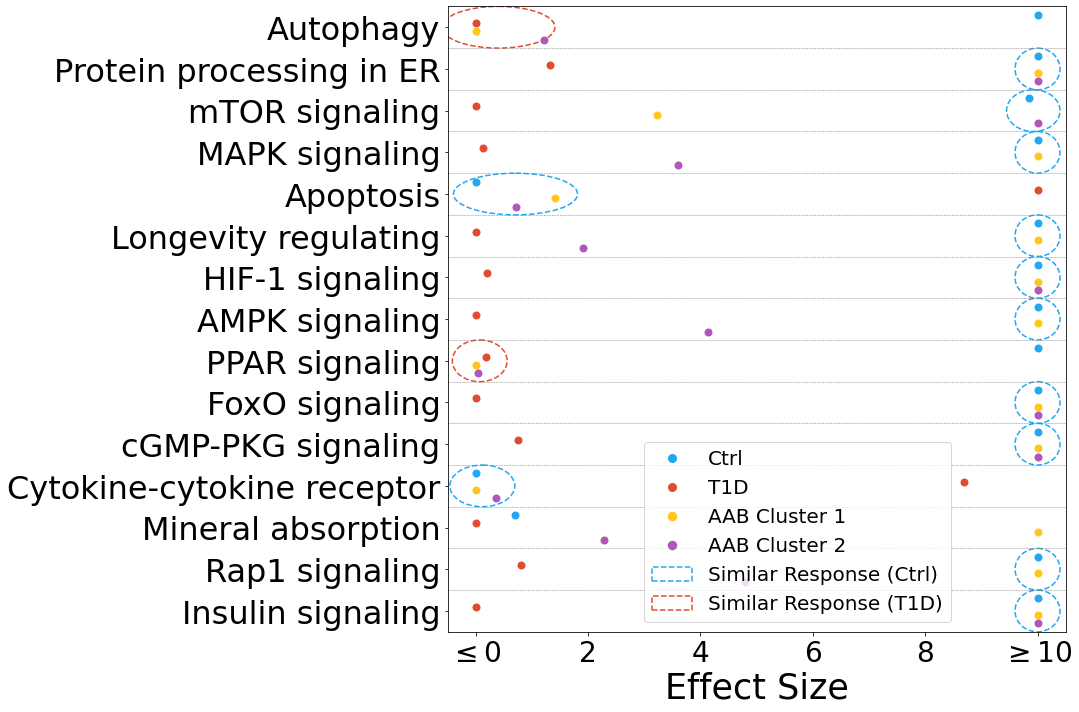

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerPatch

# ---------------------------------
# Data Preparation
# ---------------------------------
# Assume filtered_df is already created with columns 'pathway', 'z-score', and 'Group'
filtered_df['Effect_Size'] = filtered_df['z-score'].clip(lower=0, upper=10)

# Remove the word " pathway", replace "endoplasmic reticulum" with "ER", and remove " interaction"
filtered_df['pathway'] = filtered_df['pathway'].str.replace(" pathway", "", case=False)
filtered_df['pathway'] = filtered_df['pathway'].str.replace("endoplasmic reticulum", "ER", case=False)
filtered_df['pathway'] = filtered_df['pathway'].str.replace(" interaction", "", case=False)


# Define the desired ordering of pathways.
# (Update the list to match the modified labels.)
test_pathways = [
    "Autophagy",
    "Protein processing in ER",
    "mTOR signaling",
    "MAPK signaling",
    "Apoptosis",
    "Longevity regulating",
    "HIF-1 signaling",
    "AMPK signaling",
    "PPAR signaling",
    "FoxO signaling",
    "cGMP-PKG signaling",
    "Cytokine-cytokine receptor",
    "Mineral absorption",
    "Rap1 signaling",
    "Insulin signaling"
]


# Create a mapping of pathway to an order index (this will be our baseline y coordinate).
pathway_order = {path: i for i, path in enumerate(test_pathways)}

# Add a new column 'y' based on the pathway_order mapping.
filtered_df['y'] = filtered_df['pathway'].map(pathway_order)

# ---------------------------------
# Create the Base Plot Using Swarmplot
# ---------------------------------
plt.figure(figsize=(10, 8))  # initial size; we'll adjust later
ax = plt.gca()

# Define the desired color scheme.
color_dict = {
    "Ctrl": "#22a7f0",
    "T1D": "#e14b31",
    "Cluster 1": "#FFC61E",
    "Cluster 2": "#AF58BA"
}

# Use swarmplot with custom palette and hue order.
sns.swarmplot(
    data=filtered_df,
    x='Effect_Size',
    y='pathway',
    hue='Group',           # color by Group
    dodge=True,            # separate the groups horizontally
    size=8,
    palette=color_dict,
    hue_order=["Ctrl", "T1D", "Cluster 1", "Cluster 2"],
    ax=ax
)

# ---------------------------------
# Draw Dividing Horizontal Lines Between Pathways
# ---------------------------------
for i in range(1, len(test_pathways)):
    ax.axhline(i - 0.5, color='gray', linestyle='--', linewidth=0.5)

# ---------------------------------
# Set Custom X-axis Ticks with LaTeX Labels
# ---------------------------------
ticks = [0, 2, 4, 6, 8, 10]
tick_labels = [r"$\leq 0$", "2", "4", "6", "8", r"$\geq 10$"]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.tick_params(axis='y', labelsize=32)
ax.tick_params(axis='x', labelsize=28)
ax.set_xlabel("Effect Size", fontsize=35)
# Remove the y-axis label ("Pathway") but keep the tick labels.
ax.set_ylabel("")
#ax.set_title("Ctrl vs T1D vs AAB", fontsize=24, fontweight='bold')

# ---------------------------------
# Create a Custom Legend with Marker and Ellipse Entries
# ---------------------------------
# Marker entries for groups:
marker_entries = [
    Line2D([0], [0], marker='o', linestyle='None', color=color_dict['Ctrl'], label='Ctrl', markersize=8),
    Line2D([0], [0], marker='o', linestyle='None', color=color_dict['T1D'], label='T1D', markersize=8),
    # Even though the plot shows cluster points as "x", here we want dots in the legend.
    Line2D([0], [0], marker='o', linestyle='None', color=color_dict['Cluster 1'], label='AAB Cluster 1', markersize=8, markeredgewidth=1.5),
    Line2D([0], [0], marker='o', linestyle='None', color=color_dict['Cluster 2'], label='AAB Cluster 2', markersize=8, markeredgewidth=1.5)
]

# Tiny ellipse patches for reference ellipses.
ellipse_ctrl = patches.Ellipse((0.5, 0.5), 1, 0.5,
                               edgecolor=color_dict['Ctrl'],
                               facecolor='none',
                               linestyle='--',
                               linewidth=1.5,
                               label='Similar Response (Ctrl)')
ellipse_t1d = patches.Ellipse((0.5, 0.5), 1, 0.5,
                              edgecolor=color_dict['T1D'],
                              facecolor='none',
                              linestyle='--',
                              linewidth=1.5,
                              label='Similar Response (T1D)')

ellipse_entries = [ellipse_ctrl, ellipse_t1d]

# Combine all legend entries.
legend_elements = marker_entries + ellipse_entries

# Use handler_map so ellipse patches are rendered properly.
handler_map = {patches.Ellipse: HandlerPatch()}

ax.legend(handles=legend_elements, handler_map=handler_map,
          loc='upper right', bbox_to_anchor=(0.83, 0.32), bbox_transform=ax.transAxes,
          fontsize=20)

# ---------------------------------
# Overlay Ellipses to Group Close Points
# ---------------------------------
ellipse_height = 0.8      # base height for the ellipse (covering the pathway region)
extra_padding = 0.3       # extra horizontal padding to expand the ellipse
height_padding = 0.2      # extra vertical padding to expand the ellipse height

for pathway in test_pathways:
    sub = filtered_df[filtered_df['pathway'] == pathway]
    if sub.empty:
        continue

    # Baseline y coordinate for the pathway.
    y_base = pathway_order[pathway]

    # For each reference group ("Ctrl" and "T1D"), check if cluster points are within 1.5 units.
    for ref in ['Ctrl', 'T1D']:
        ref_data = sub[sub['Group'] == ref]
        if ref_data.empty:
            continue
        ref_val = ref_data['Effect_Size'].values[0]
        pts = [ref_val]
        for cl in ['Cluster 1', 'Cluster 2']:
            cl_data = sub[sub['Group'] == cl]
            if not cl_data.empty:
                cl_val = cl_data['Effect_Size'].values[0]
                if abs(cl_val - ref_val) <= 1.5:
                    pts.append(cl_val)
        if len(pts) > 1:
            center_x = np.mean(pts)
            # Expand the ellipse width with extra padding.
            width = (max(pts) - min(pts)) + 0.5 + extra_padding
            adj_height = ellipse_height + height_padding
            # Set the edge color to that of the current reference group.
            ellipse = patches.Ellipse((center_x, y_base), width, adj_height,
                                      edgecolor=color_dict[ref],
                                      facecolor='none',
                                      linestyle='--',
                                      linewidth=1.5)
            ax.add_patch(ellipse)

# Adjust the overall figure size (wider)
fig = plt.gcf()
fig.set_size_inches(15, 10)

plt.tight_layout()
plt.savefig("/work/of21_work/AAB_march_31.jpeg", dpi=600, bbox_inches="tight")
plt.show()


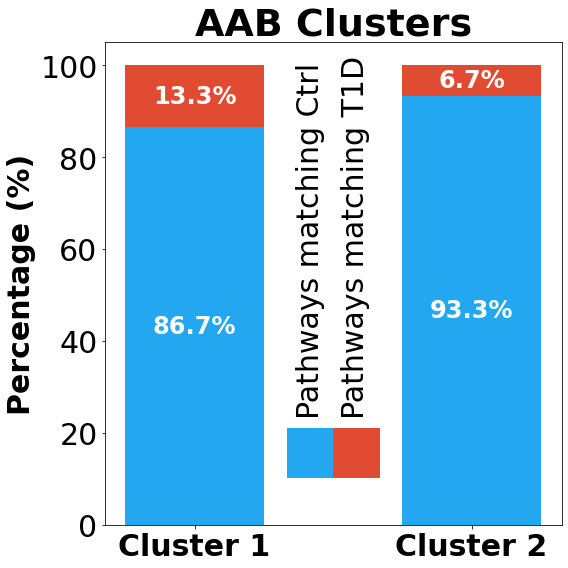

In [8]:
# Prepare DataFrames for the bar chart.
df_ctrl     = filtered_df[filtered_df['Group'] == 'Ctrl'][['pathway', 'adjusted p-value']]
df_t1d      = filtered_df[filtered_df['Group'] == 'T1D'][['pathway', 'adjusted p-value']]
df_cluster1 = filtered_df[filtered_df['Group'] == 'Cluster 1'][['pathway', 'adjusted p-value']]
df_cluster2 = filtered_df[filtered_df['Group'] == 'Cluster 2'][['pathway', 'adjusted p-value']]

# --- STEP 2: Merge Cluster 1 with Ctrl and T1D by pathway ---
cluster1 = df_cluster1.merge(df_ctrl, on='pathway', suffixes=('_cluster', '_ctrl'))
cluster1 = cluster1.merge(df_t1d, on='pathway')
# The merge with df_t1d brings in an "adjusted p-value" column;
# rename it to 'p-value_t1d' for clarity
cluster1.rename(columns={'adjusted p-value': 'p-value_t1d'}, inplace=True)

# --- STEP 3: Define similarity for Cluster 1 ---
# Similarity is defined as both values being below 0.05 or both above (or equal to) 0.05.
cluster1['similar_ctrl'] = (
    ((cluster1['adjusted p-value_cluster'] < 0.05) & (cluster1['adjusted p-value_ctrl'] < 0.05)) |
    ((cluster1['adjusted p-value_cluster'] >= 0.05) & (cluster1['adjusted p-value_ctrl'] >= 0.05))
)
cluster1['similar_t1d'] = (
    ((cluster1['adjusted p-value_cluster'] < 0.05) & (cluster1['p-value_t1d'] < 0.05)) |
    ((cluster1['adjusted p-value_cluster'] >= 0.05) & (cluster1['p-value_t1d'] >= 0.05))
)

# --- STEP 4: Calculate percentages for Cluster 1 ---
total_cluster1 = len(cluster1)
perc_similar_ctrl_cluster1 = cluster1['similar_ctrl'].sum() / total_cluster1 * 100
perc_similar_t1d_cluster1  = cluster1['similar_t1d'].sum() / total_cluster1 * 100

# --- Repeat Steps 2-4 for Cluster 2 ---
cluster2 = df_cluster2.merge(df_ctrl, on='pathway', suffixes=('_cluster', '_ctrl'))
cluster2 = cluster2.merge(df_t1d, on='pathway')
# Rename the T1D "adjusted p-value" column to 'pvalue_t1d'
cluster2.rename(columns={'adjusted p-value': 'pvalue_t1d'}, inplace=True)

cluster2['similar_ctrl'] = (
    ((cluster2['adjusted p-value_cluster'] < 0.05) & (cluster2['adjusted p-value_ctrl'] < 0.05)) |
    ((cluster2['adjusted p-value_cluster'] >= 0.05) & (cluster2['adjusted p-value_ctrl'] >= 0.05))
)
cluster2['similar_t1d'] = (
    ((cluster2['adjusted p-value_cluster'] < 0.05) & (cluster2['pvalue_t1d'] < 0.05)) |
    ((cluster2['adjusted p-value_cluster'] >= 0.05) & (cluster2['pvalue_t1d'] >= 0.05))
)

total_cluster2 = len(cluster2)
perc_similar_ctrl_cluster2 = cluster2['similar_ctrl'].sum() / total_cluster2 * 100
perc_similar_t1d_cluster2  = cluster2['similar_t1d'].sum() / total_cluster2 * 100

# --- STEP 5: Create Stacked Bar Plot ---
clusters = ['Cluster 1', 'Cluster 2']
similar_ctrl = [perc_similar_ctrl_cluster1, perc_similar_ctrl_cluster2]
similar_t1d  = [perc_similar_t1d_cluster1,  perc_similar_t1d_cluster2]

# Create a new figure for the bar plot only
fig, ax = plt.subplots(figsize=(8, 8))

# Define positions and bar width
x = np.arange(len(clusters))
bar_width = 0.5

# Create the stacked bar chart
bar1 = ax.bar(x, similar_ctrl, bar_width, color='#22a7f0', label='Pathways matching Ctrl')
bar2 = ax.bar(x, similar_t1d, bar_width, bottom=similar_ctrl, color='#e14b31', label='Pathways matching T1D')

# Add text labels inside the bars
for i in range(len(x)):
    ax.text(x[i], similar_ctrl[i] / 2, f'{similar_ctrl[i]:.1f}%', ha='center', va='center',
            fontsize=24, fontweight='bold', color='white')
    ax.text(x[i], similar_ctrl[i] + similar_t1d[i] / 2, f'{similar_t1d[i]:.1f}%', ha='center', va='center',
            fontsize=24, fontweight='bold', color='white')

# Customize the axes
ax.set_xticks(x)
ax.set_xticklabels(clusters, fontsize=30, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=30, fontweight='bold')
ax.tick_params(axis='y', labelsize=30)

ax.set_title('AAB Clusters', fontsize=38, fontweight='bold')

# Create a custom legend inside the bar plot
# Define positions in axes-relative coordinates (0-1)
legend1_x = 0.45  # Center x for Ctrl legend item
legend2_x = 0.55  # Center x for T1D legend item
legend_y = 0.15   # Vertical position for the legend items
square_size = 0.1

# For Ctrl (blue)
blue_square = patches.Rectangle((legend1_x - square_size/2, legend_y - square_size/2),
                                  square_size, square_size,
                                  transform=ax.transAxes,
                                  color='#22a7f0', clip_on=False)
ax.add_patch(blue_square)
ax.text(legend1_x, legend_y + square_size/2 + 0.02,
        "Pathways matching Ctrl",
        rotation=90, transform=ax.transAxes,
        ha='center', va='bottom', fontsize=30)

# For T1D (red/orange)
red_square = patches.Rectangle((legend2_x - square_size/2, legend_y - square_size/2),
                                 square_size, square_size,
                                 transform=ax.transAxes,
                                 color='#e14b31', clip_on=False)
ax.add_patch(red_square)
ax.text(legend2_x, legend_y + square_size/2 + 0.02,
        "Pathways matching T1D",
        rotation=90, transform=ax.transAxes,
        ha='center', va='bottom', fontsize=30)

plt.tight_layout()
plt.savefig("/work/of21_work/AAB_barplot_alone_final.jpeg", dpi=600, bbox_inches="tight")

plt.show()